<a href="https://colab.research.google.com/github/azhgh22/Monet_Style_Generator/blob/main/notebooks/run1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Set Env**

In [1]:
%%capture
from google.colab import drive
drive.mount('/content/drive')

from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')
user_name = userdata.get('GITHUB_USERNAME')
mail = userdata.get('GITHUB_MAIL')

!git config --global user.name "{user_name}"
!git config --global user.email "{mail}"
!git clone https://{token}@github.com/azhgh22/Monet_Style_Generator.git

# **Imports**

In [2]:
import sys
import os
import torch

# Add the root directory of the cloned repository to the Python path
sys.path.append('/content/Monet_Style_Generator')

import importlib
import utils.custom_dataset as custom_dataset_module
import utils.train_test_split as tts_module
import utils.dataset_assembly as ds_assembly_module
import utils.weight_initializer as weight_initializer
importlib.reload(custom_dataset_module)
importlib.reload(tts_module)
importlib.reload(ds_assembly_module)
importlib.reload(weight_initializer)
from utils.custom_dataset import CustomDataset
from utils.dataset_assembly import DatasetAssembly
from utils.train_test_split import TrainTestSplit
from utils.weight_initializer import WeightsInitializer
from pathlib import Path
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# **Read Data and Split data**

In [3]:
train, val, test = TrainTestSplit("/content/Monet_Style_Generator/data/photo_jpg/").split(0.7,0.15,0.15)

In [4]:
monet_pictures = list(Path("/content/Monet_Style_Generator/data/monet_jpg/").glob('*.jpg'))

In [5]:
# create datasets
train_part = CustomDataset(train)
val_dataset = CustomDataset(val)
test_dataset = CustomDataset(test)

monet_dataset = CustomDataset(monet_pictures)

train_dataset = DatasetAssembly(train_part, monet_dataset)

In [6]:

import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from torchvision.utils import make_grid

def show_img(x: torch.Tensor):
  x = x.detach().cpu()
  x = x.permute(1, 2, 0)

  plt.imshow(x)
  plt.axis("off")
  plt.show()

# **Data Loaders**

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
)

val_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True,
  )

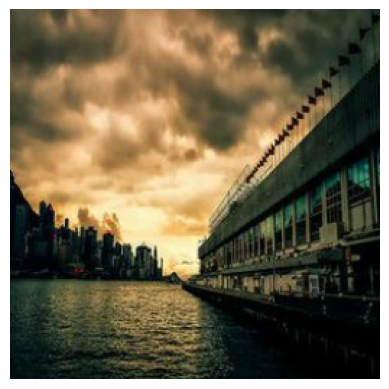

In [ ]:
show_img(train_dataset[0][0])

In [8]:
import models.GAN.generator_models.resnet_gen as res_gen
import models.GAN.discriminator_models.patchgan as patchgan
import models.GAN.cycle_gan as cycle_gan
import utils.train as train_module
import utils.checkpointer as checkpointer_module
importlib.reload(res_gen)
importlib.reload(patchgan)
importlib.reload(cycle_gan)
importlib.reload(train_module)
importlib.reload(checkpointer_module)
from models.GAN.generator_models.resnet_gen import ResnetGenerator
from models.GAN.discriminator_models.patchgan import PatchGANDiscriminator
from models.GAN.cycle_gan import CycleGAN
from utils.train import Train
from utils.checkpointer import Checkpointer

# **Train Loop**

In [9]:
%%capture
EPOCHS = 200

monet_generator = ResnetGenerator()
monet_discriminator = PatchGANDiscriminator()

picture_generator = ResnetGenerator()
picture_discriminator = PatchGANDiscriminator()

model = CycleGAN(monet_generator, picture_generator, monet_discriminator, picture_discriminator).to(device)

## init model weights from Normal (0, 0.002)
wi = WeightsInitializer()
model.apply(wi)



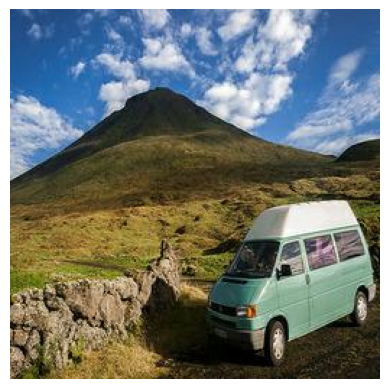

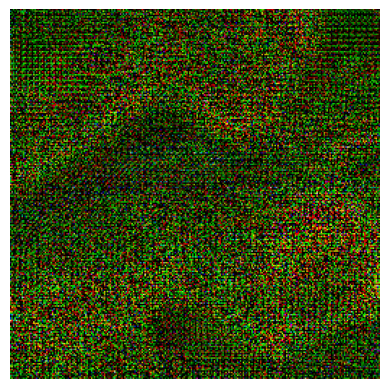

In [10]:
gen_img = monet_generator.forward(train_dataset[0][0].to(device))
show_img(train_dataset[0][0])
show_img(gen_img)

In [11]:
checkpoint_dir = "/content/drive/MyDrive/checkpoints/cycle_gan_resnet_v1"

checkpointer = Checkpointer(checkpoint_dir,"cycle_gan",1)
train = Train(model, 30, train_loader, checkpointer, device)
train.load_checkpoint()
# train.train()

Loaded latest checkpoint: /content/drive/MyDrive/checkpoints/cycle_gan_resnet_v1/cycle_gan_epoch_4.pt


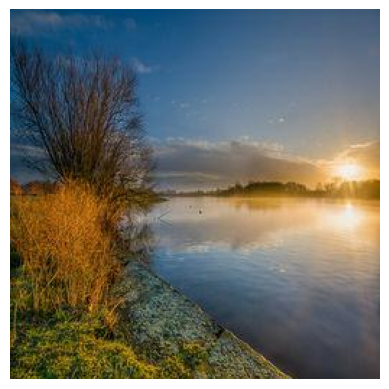

In [18]:
show_img(val_dataset[3].to(device))

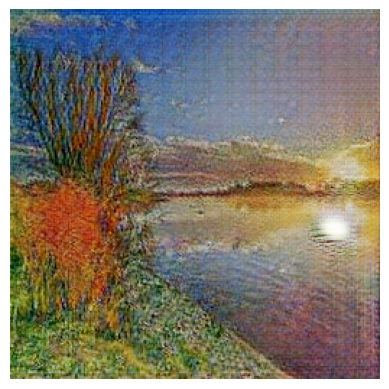

In [19]:
gen = monet_generator.forward(val_dataset[3].to(device))
show_img(gen)